# Notebook 04 — Statistical Analysis of Training Data

**Purpose:** Statistical deep-dive on the exact data that was used to train the MLP — focusing on properties that explain model behaviour seen in evaluation (price cap bias, coastal under-prediction, income dominance).

This notebook uses **only** the features that exist in `X_train`/`X_test`:
- 8 original numeric features (standardised)
- 5 one-hot columns from `ocean_proximity`
- Target: `median_house_value / 100 000` (hard-capped at 5.0)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid', font_scale=1.1)
FIG_DPI  = 150
TITLE_FS = 14
LABEL_FS = 12
SCALE    = 100_000.0
CAP_USD  = 500_000
CAP_SCALED = 5.0
plt.rcParams.update({'figure.dpi': FIG_DPI, 'savefig.bbox': 'tight'})

VIZ_DIR = '../../data/visualize'
os.makedirs(VIZ_DIR, exist_ok=True)

# ── Load raw, reproduce preprocessing exactly as notebook 02 does ─────────
df = pd.read_csv('../../data/raw/housing.csv').dropna().reset_index(drop=True)

NUMERIC = ['longitude','latitude','housing_median_age',
           'total_rooms','total_bedrooms','population',
           'households','median_income']
TARGET  = 'median_house_value'

df_enc = pd.get_dummies(df, columns=['ocean_proximity'], dtype=float)
X_all  = df_enc.drop(columns=[TARGET]).values
y_all  = (df_enc[TARGET].values / SCALE).reshape(-1, 1)

X_train_raw, X_test_raw, y_train, y_test, idx_tr, idx_te = train_test_split(
    X_all, y_all, range(len(df)), test_size=0.2, random_state=42
)
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

FEATURE_NAMES = list(df_enc.drop(columns=[TARGET]).columns)
print(f'Training features ({len(FEATURE_NAMES)}): {FEATURE_NAMES}')
print(f'Train: {X_train.shape}  Test: {X_test.shape}')
print(f'y_train range: [{y_train.min():.3f}, {y_train.max():.3f}]  (scaled by /100000)')

Training features (13): ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']
Train: (16346, 13)  Test: (4087, 13)
y_train range: [0.150, 5.000]  (scaled by /100000)


---
## 1 · Target Variable Statistics
### 📊 PLOT 1 — Target Distribution Fitting (Normal vs Log-Normal)
**What it shows:** Histogram with fitted Normal and Log-Normal PDFs.  
**Presentation use:** The log-normal fits far better — the target is inherently right-skewed. This matters for MLP training because MSE penalises large residuals symmetrically, but the target is not symmetric.

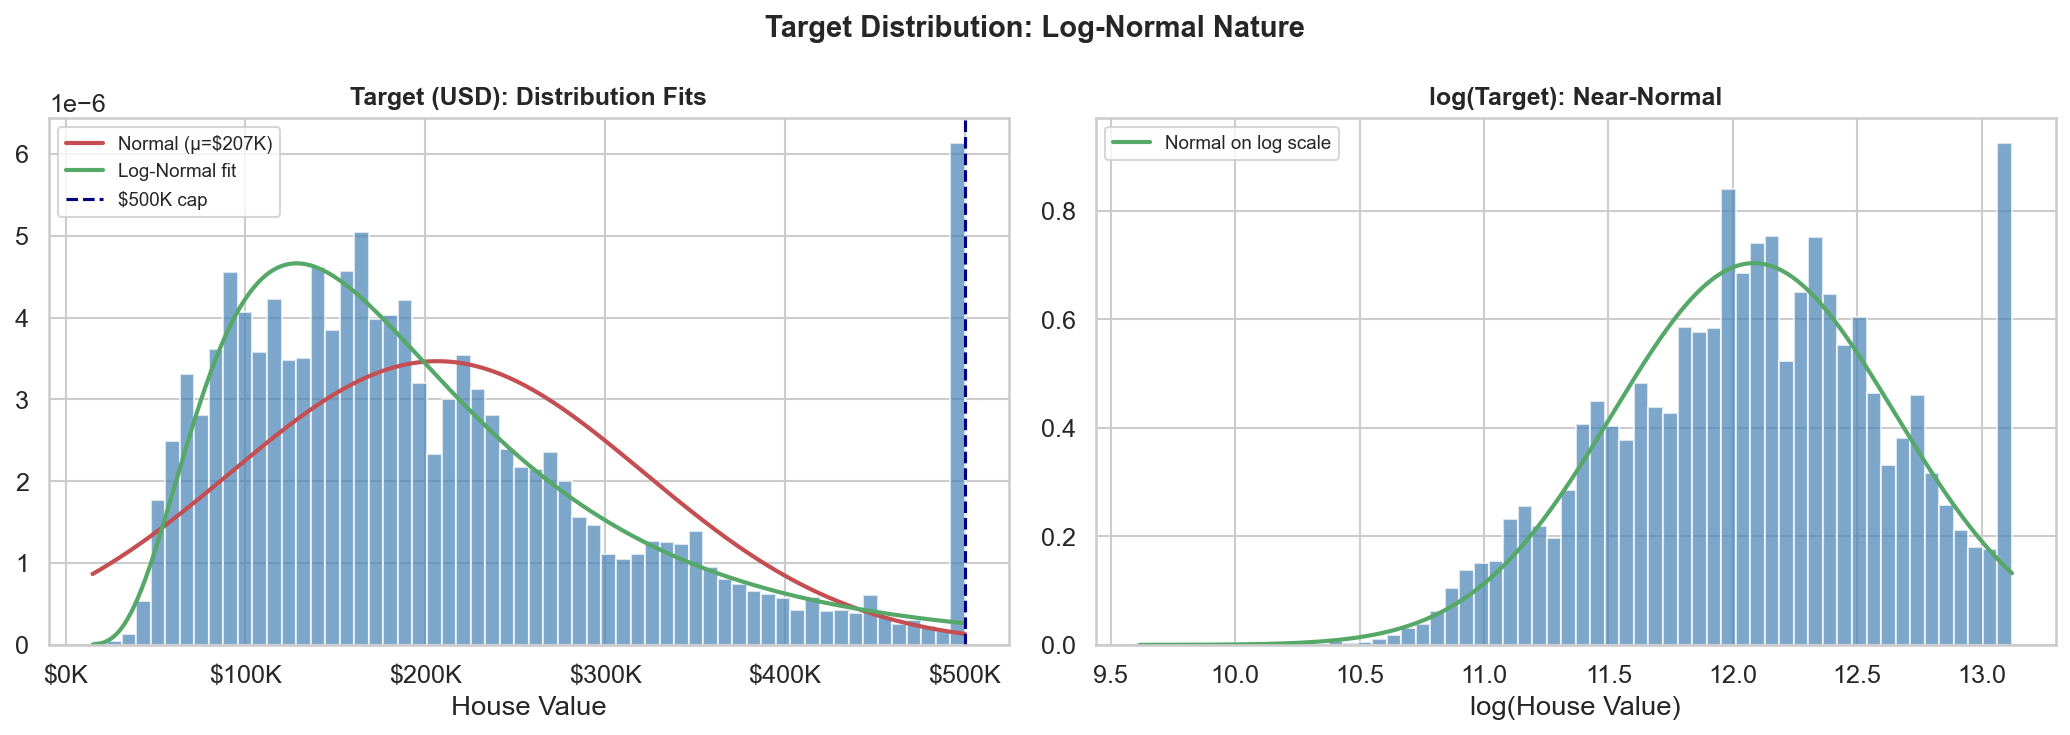

In [2]:
y_usd = y_train.flatten() * SCALE   # back to USD for readable axes

mu_n, std_n = stats.norm.fit(y_usd)
shape_ln, loc_ln, scale_ln = stats.lognorm.fit(y_usd, floc=0)
x_range = np.linspace(y_usd.min(), y_usd.max(), 500)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(y_usd, bins=60, density=True, color='steelblue', alpha=0.7, edgecolor='white')
axes[0].plot(x_range, stats.norm.pdf(x_range, mu_n, std_n),
             'r-', lw=2, label=f'Normal (μ=${mu_n/1e3:.0f}K)')
axes[0].plot(x_range, stats.lognorm.pdf(x_range, shape_ln, loc_ln, scale_ln),
             'g-', lw=2, label='Log-Normal fit')
axes[0].axvline(CAP_USD, color='navy', linestyle='--', linewidth=1.5, label='$500K cap')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
axes[0].set_title('Target (USD): Distribution Fits', fontsize=12, fontweight='bold')
axes[0].set_xlabel('House Value')
axes[0].legend(fontsize=9)

log_vals = np.log(y_usd)
x_log = np.linspace(log_vals.min(), log_vals.max(), 400)
axes[1].hist(log_vals, bins=60, density=True, color='steelblue', alpha=0.7, edgecolor='white')
axes[1].plot(x_log, stats.norm.pdf(x_log, log_vals.mean(), log_vals.std()),
             'g-', lw=2, label='Normal on log scale')
axes[1].set_title('log(Target): Near-Normal', fontsize=12, fontweight='bold')
axes[1].set_xlabel('log(House Value)')
axes[1].legend(fontsize=9)

fig.suptitle('Target Distribution: Log-Normal Nature',
             fontsize=TITLE_FS, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/plot04_01_distribution_fitting.png', dpi=FIG_DPI)
plt.show()

---
### 📊 PLOT 2 — Q-Q Plot: Target Normality Check
**What it shows:** Quantile-quantile plot — straight diagonal = normal distribution.  
**Presentation use:** The S-curve and flat right tail confirm non-normality; the flat tail IS the $500K cap. Log-transforming fixes most of the non-normality.

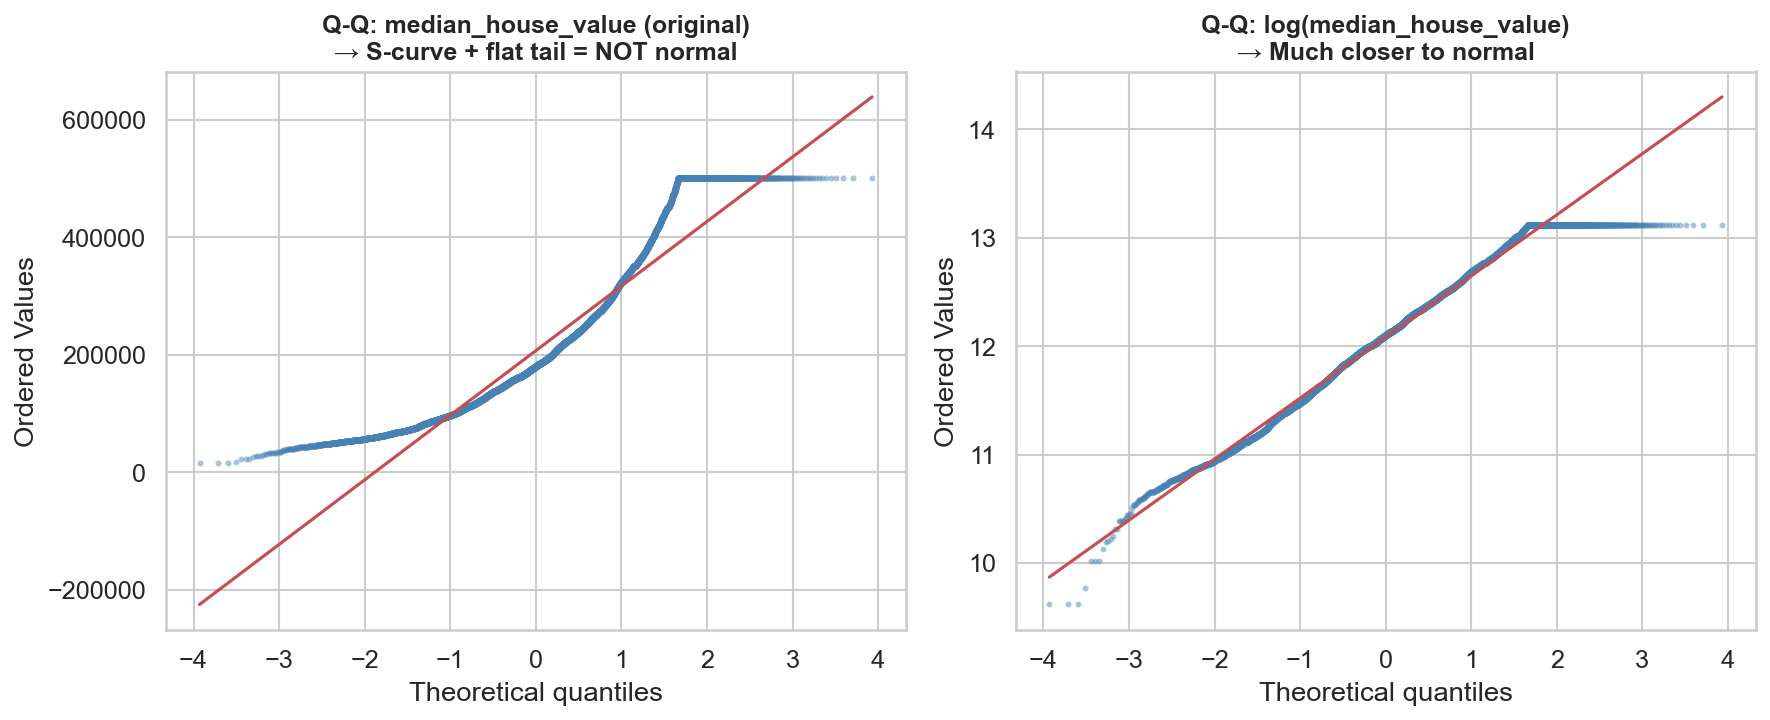

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

stats.probplot(y_usd, dist='norm', plot=axes[0])
axes[0].get_lines()[0].set(markersize=2, alpha=0.35, color='steelblue')
axes[0].set_title('Q-Q: median_house_value (original)\n→ S-curve + flat tail = NOT normal',
                  fontsize=12, fontweight='bold')

stats.probplot(np.log1p(y_usd), dist='norm', plot=axes[1])
axes[1].get_lines()[0].set(markersize=2, alpha=0.35, color='steelblue')
axes[1].set_title('Q-Q: log(median_house_value)\n→ Much closer to normal',
                  fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/plot04_02_qq_plots.png', dpi=FIG_DPI)
plt.show()

---
## 2 · The $500K Price Cap — Understanding a Core Data Issue
### 📊 PLOT 3 — Price Cap: Where Is It, How Many Districts, How Much Error?
**What it shows:** Three panels — (a) distribution with cap highlighted, (b) count by proximity category at/near cap, (c) what fraction of each category hits the cap.  
**Presentation use:** Directly explains the systematic under-prediction found in the evaluation notebook — capped districts force the model to learn incorrect signals.

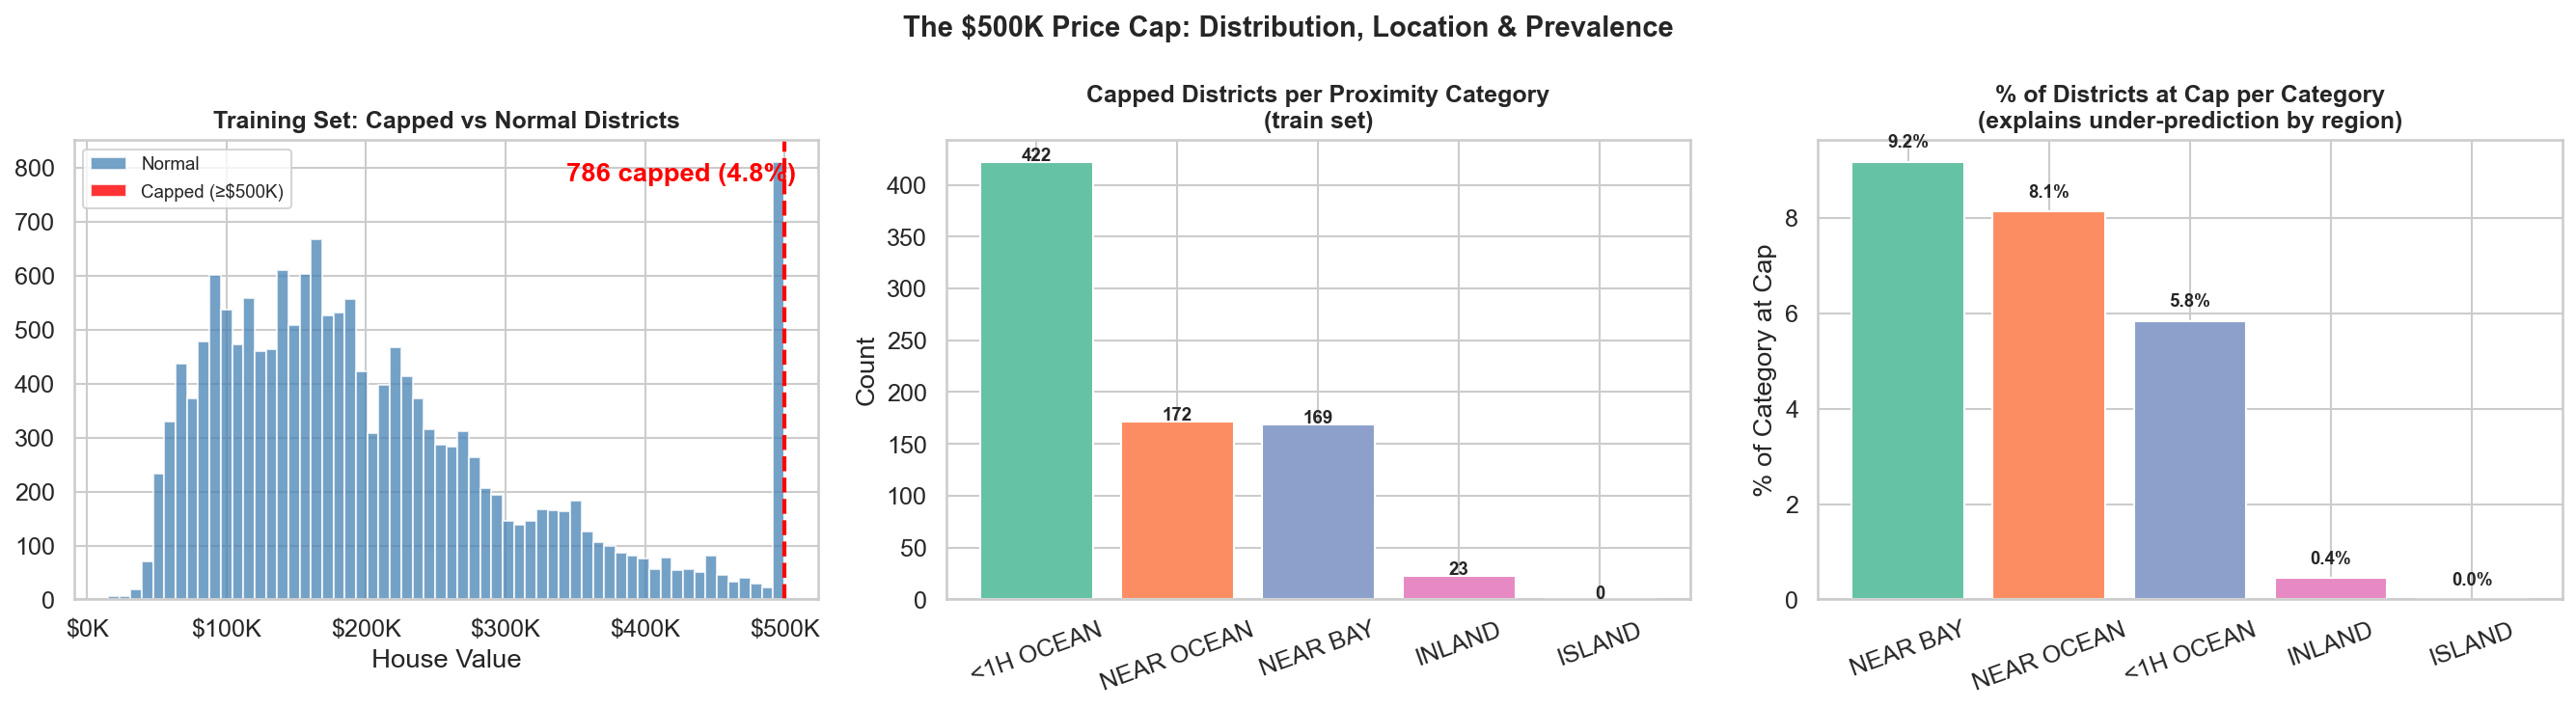

In [4]:
df_tr = df.iloc[list(idx_tr)].copy().reset_index(drop=True)
df_te = df.iloc[list(idx_te)].copy().reset_index(drop=True)

df_tr['capped'] = df_tr[TARGET] >= CAP_USD
df_te['capped'] = df_te[TARGET] >= CAP_USD

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel A: histogram with cap zone shaded
axes[0].hist(df_tr[TARGET], bins=60, color='steelblue', alpha=0.75, edgecolor='white', label='Normal')
capped_vals = df_tr.loc[df_tr['capped'], TARGET]
axes[0].hist(capped_vals, bins=15, color='red', alpha=0.8, edgecolor='white', label='Capped (≥$500K)')
axes[0].axvline(CAP_USD, color='red', linestyle='--', linewidth=2)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
axes[0].set_title('Training Set: Capped vs Normal Districts', fontsize=12, fontweight='bold')
axes[0].set_xlabel('House Value')
axes[0].legend(fontsize=9)
n_cap = df_tr['capped'].sum()
axes[0].text(0.97, 0.95, f'{n_cap} capped ({n_cap/len(df_tr)*100:.1f}%)',
             transform=axes[0].transAxes, ha='right', va='top', color='red', fontweight='bold')

# Panel B: capped count per ocean_proximity
cap_by_prox = df_tr.groupby('ocean_proximity')['capped'].sum().sort_values(ascending=False)
bars = axes[1].bar(cap_by_prox.index, cap_by_prox.values,
                   color=sns.color_palette('Set2', len(cap_by_prox)), edgecolor='white')
for bar, v in zip(bars, cap_by_prox.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 str(v), ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Capped Districts per Proximity Category\n(train set)', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)
axes[1].set_ylabel('Count')

# Panel C: % capped per category
cap_pct = (df_tr.groupby('ocean_proximity')['capped'].mean() * 100).sort_values(ascending=False)
bars2 = axes[2].bar(cap_pct.index, cap_pct.values,
                    color=sns.color_palette('Set2', len(cap_pct)), edgecolor='white')
for bar, v in zip(bars2, cap_pct.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[2].set_title('% of Districts at Cap per Category\n(explains under-prediction by region)',
                  fontsize=12, fontweight='bold')
axes[2].tick_params(axis='x', rotation=20)
axes[2].set_ylabel('% of Category at Cap')

fig.suptitle('The $500K Price Cap: Distribution, Location & Prevalence',
             fontsize=TITLE_FS, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/plot04_03_price_cap_analysis.png', dpi=FIG_DPI)
plt.show()

---
### 📊 PLOT 4 — Geographic Location of Capped Districts
**What it shows:** California map where red = capped district (≥$500K), blue = normal.  
**Presentation use:** Spatially confirms what the evaluation notebook found — coastal/urban zones (Bay Area, LA) have the most capped points, which explains the regional under-prediction pattern.

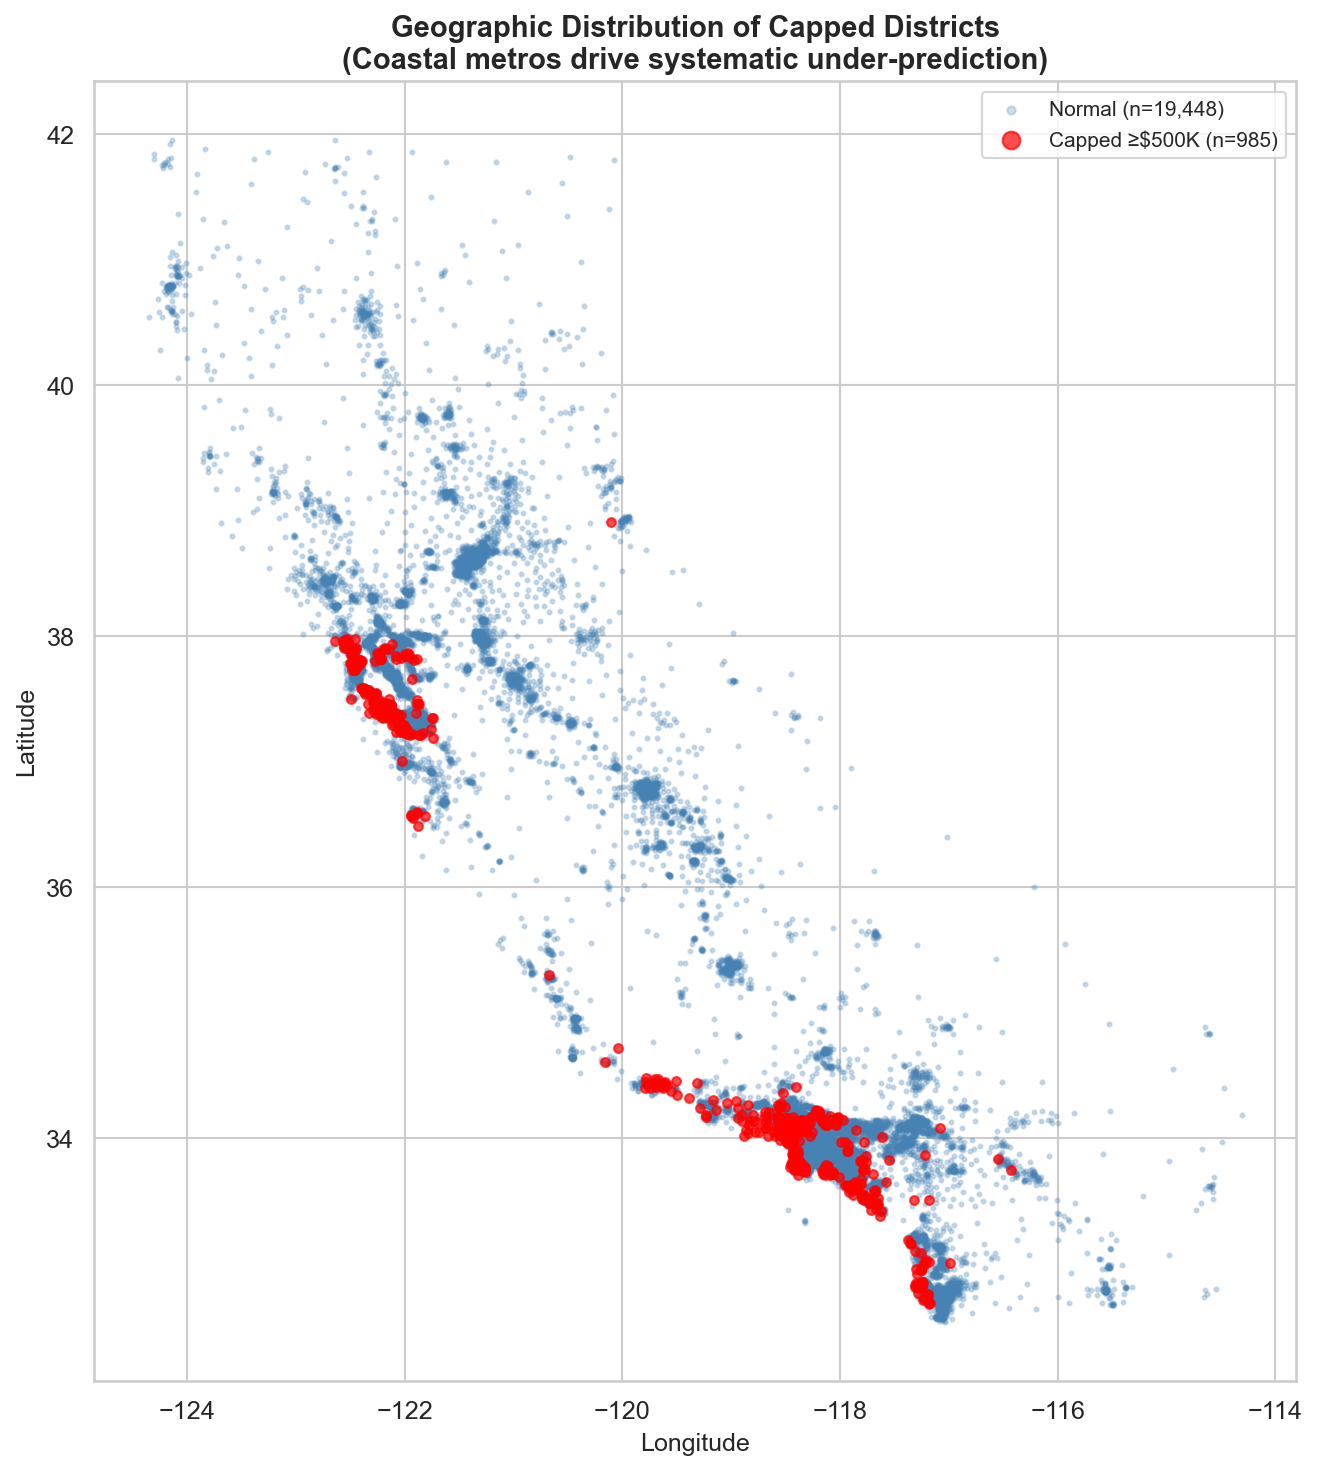

In [5]:
fig, ax = plt.subplots(figsize=(9, 10))

normal_df  = df[df[TARGET] < CAP_USD]
capped_df  = df[df[TARGET] >= CAP_USD]

ax.scatter(normal_df['longitude'], normal_df['latitude'],
           s=4, alpha=0.25, color='steelblue', label=f'Normal (n={len(normal_df):,})')
ax.scatter(capped_df['longitude'], capped_df['latitude'],
           s=18, alpha=0.7, color='red', label=f'Capped ≥$500K (n={len(capped_df):,})', zorder=5)

ax.set_xlabel('Longitude', fontsize=LABEL_FS)
ax.set_ylabel('Latitude',  fontsize=LABEL_FS)
ax.set_title('Geographic Distribution of Capped Districts\n'
             '(Coastal metros drive systematic under-prediction)',
             fontsize=TITLE_FS, fontweight='bold')
ax.legend(fontsize=10, markerscale=2)
plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/plot04_04_capped_geo_map.png', dpi=FIG_DPI)
plt.show()

---
## 3 · Statistical Group Comparisons
### 📊 PLOT 5 — ANOVA: Price by Ocean Proximity (with test result)
**What it shows:** Violin + ANOVA F-statistic/p-value for price differences across the 5 ocean proximity groups.  
**Presentation use:** The five categories the model learns via one-hot encoding are statistically distinct — not arbitrary labels. This justifies their inclusion as features.

One-Way ANOVA  →  F = 1594.7,  p = 0.00e+00


C:\Users\TDV\AppData\Local\Temp\ipykernel_28216\4095202782.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


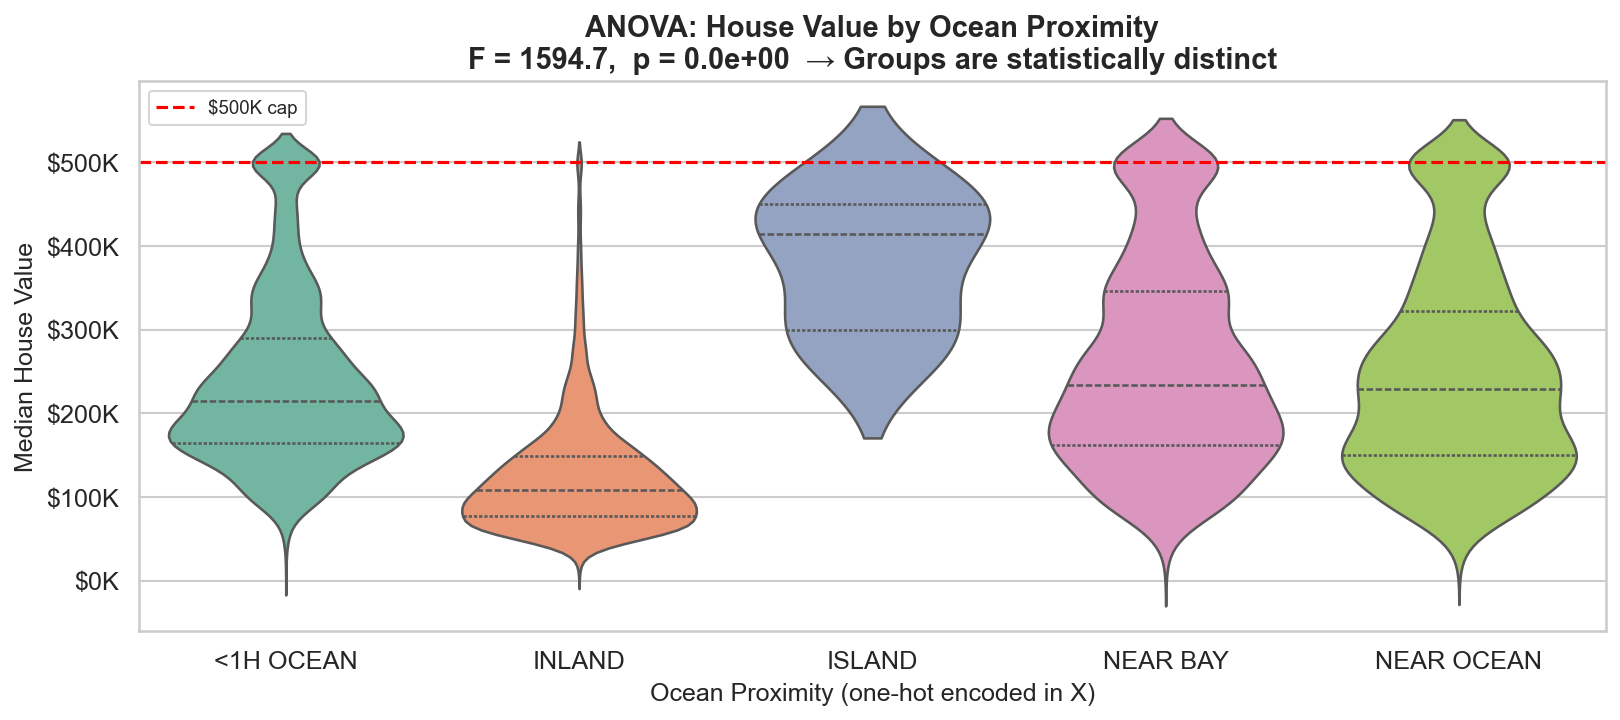

In [6]:
prox_order = sorted(df['ocean_proximity'].unique())
groups = [df.loc[df['ocean_proximity']==g, TARGET].values for g in prox_order]
f_stat, p_val = stats.f_oneway(*groups)
print(f'One-Way ANOVA  →  F = {f_stat:.1f},  p = {p_val:.2e}')

fig, ax = plt.subplots(figsize=(11, 5))
sns.violinplot(
    data=df, x='ocean_proximity', y=TARGET,
    order=prox_order, palette='Set2',
    inner='quartile', ax=ax
)
ax.axhline(CAP_USD, color='red', linestyle='--', linewidth=1.5, label='$500K cap')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax.set_xlabel('Ocean Proximity (one-hot encoded in X)', fontsize=LABEL_FS)
ax.set_ylabel('Median House Value', fontsize=LABEL_FS)
ax.set_title(f'ANOVA: House Value by Ocean Proximity\n'
             f'F = {f_stat:.1f},  p = {p_val:.1e}  → Groups are statistically distinct',
             fontsize=TITLE_FS, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/plot04_05_anova_ocean_proximity.png', dpi=FIG_DPI)
plt.show()

---
### 📊 PLOT 6 — IQR Outlier Percentage per Training Feature
**What it shows:** What fraction of rows are IQR outliers for each of the 8 numeric features.  
**Presentation use:** High outlier rates in count features mean the MLP receives very large input values (even after scaling), which can destabilise training.

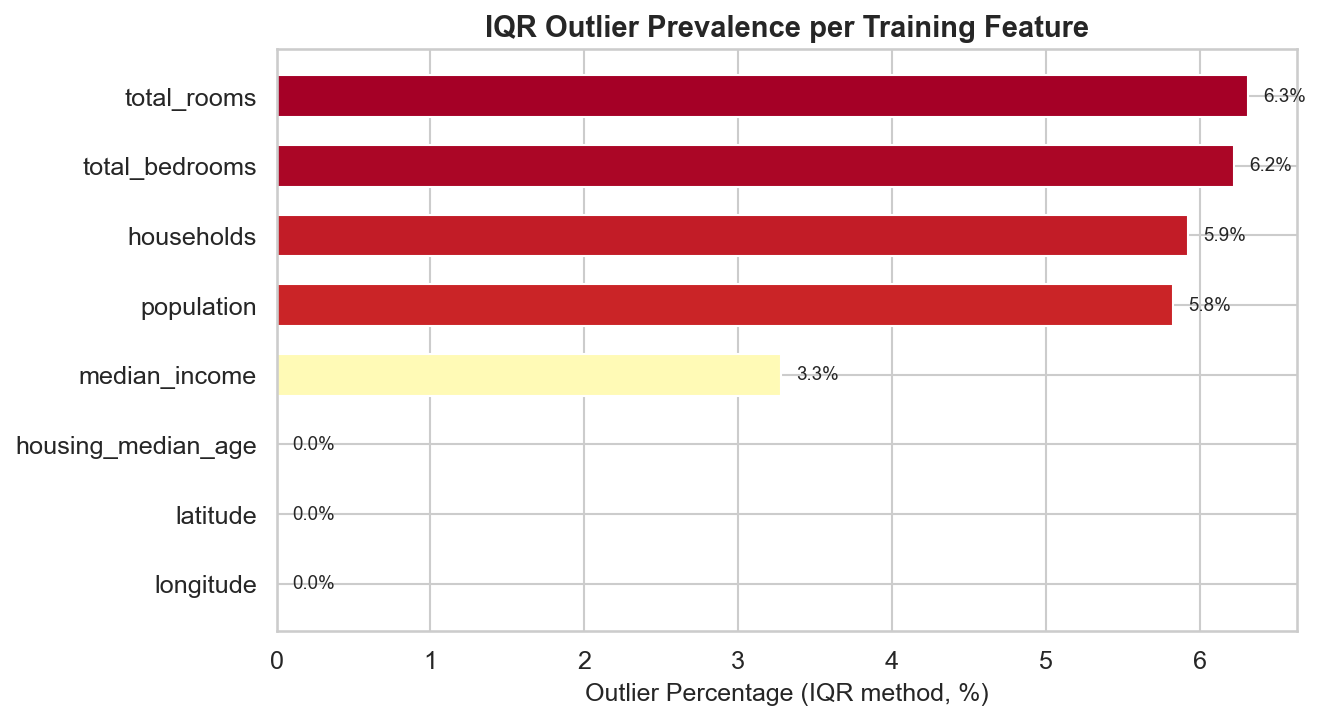

In [7]:
outlier_pct = {}
for col in NUMERIC:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    outlier_pct[col] = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).mean() * 100

out_s = pd.Series(outlier_pct).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = plt.cm.RdYlGn_r(out_s.values / out_s.max())
bars = ax.barh(out_s.index, out_s.values, color=bar_colors, edgecolor='white', height=0.6)
for bar, val in zip(bars, out_s.values):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
ax.set_xlabel('Outlier Percentage (IQR method, %)', fontsize=LABEL_FS)
ax.set_title('IQR Outlier Prevalence per Training Feature',
             fontsize=TITLE_FS, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/plot04_06_iqr_outliers.png', dpi=FIG_DPI)
plt.show()

---
### 📊 PLOT 7 — Feature Value Ranges by Ocean Proximity
**What it shows:** Box plots of all 8 numeric features split by ocean proximity category.  
**Presentation use:** Shows what the model must discriminate — ISLAND and NEAR BAY districts have distinct value ranges that the one-hot flags help the MLP separate.

C:\Users\TDV\AppData\Local\Temp\ipykernel_28216\3447672803.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\TDV\AppData\Local\Temp\ipykernel_28216\3447672803.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\TDV\AppData\Local\Temp\ipykernel_28216\3447672803.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\TDV\AppData\Local\Temp\ipykernel_28216\3447672803.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set 

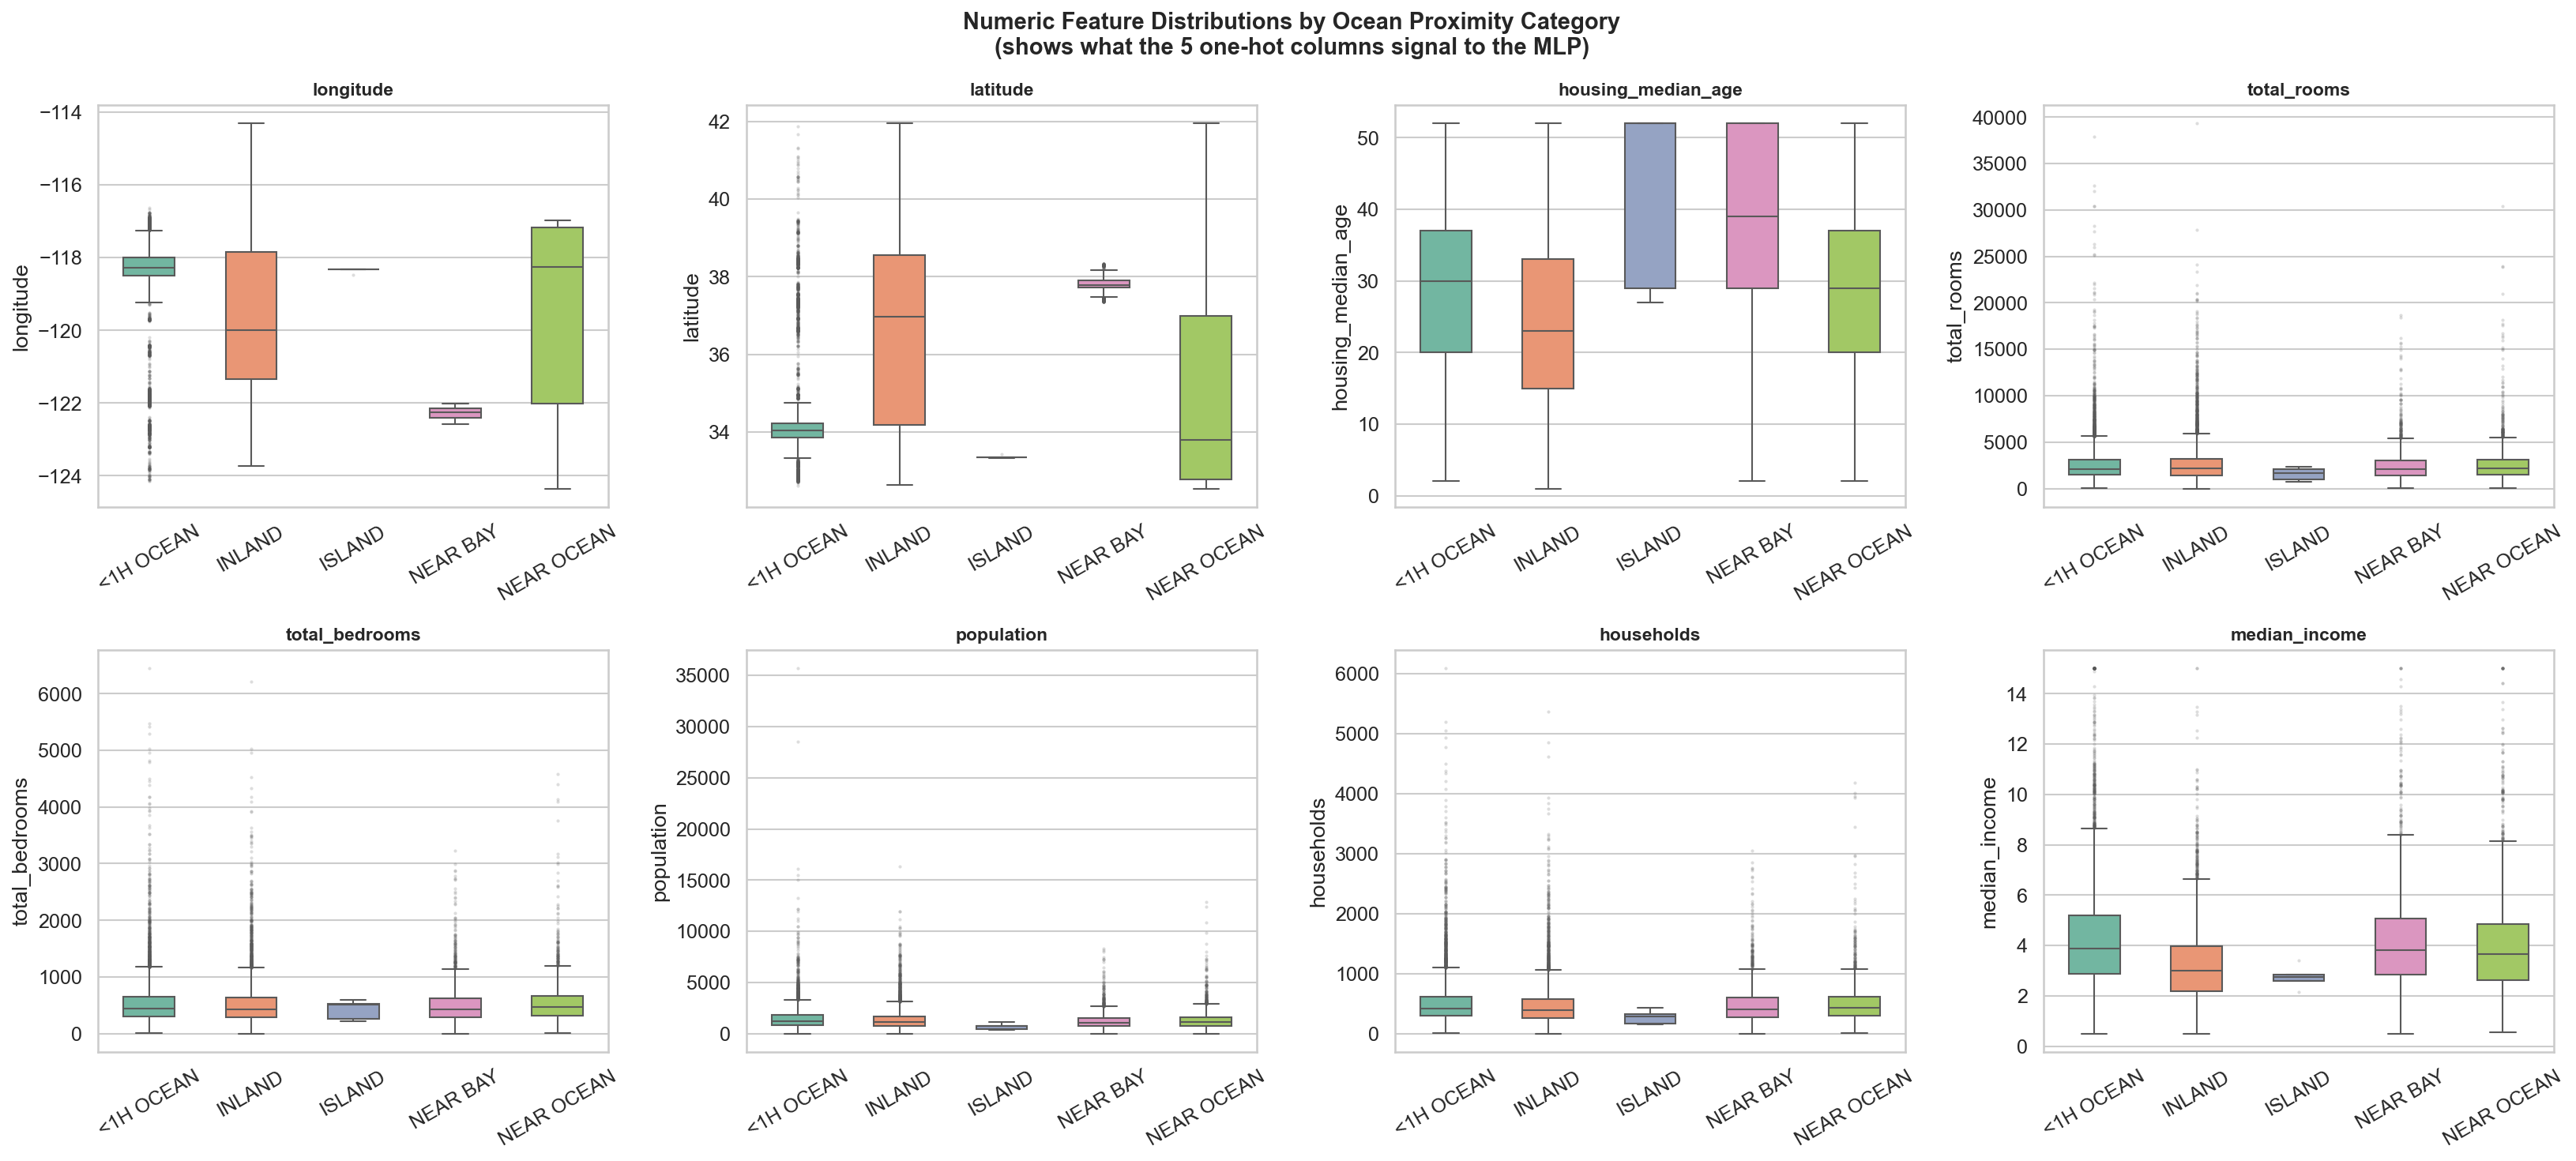

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))

for ax, col in zip(axes.flat, NUMERIC):
    sns.boxplot(
        data=df, x='ocean_proximity', y=col,
        order=prox_order, palette='Set2', ax=ax, width=0.5,
        flierprops=dict(marker='.', markersize=2, alpha=0.2)
    )
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)

fig.suptitle('Numeric Feature Distributions by Ocean Proximity Category\n'
             '(shows what the 5 one-hot columns signal to the MLP)',
             fontsize=TITLE_FS, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/plot04_07_features_by_proximity.png', dpi=FIG_DPI)
plt.show()

---
## 4 · Geographic Patterns in Training Data
### 📊 PLOT 8 — Price Heatmap Grid (Latitude × Longitude)
**What it shows:** California divided into a fine grid, each cell coloured by mean house value.  
**Presentation use:** Explains why `latitude` and `longitude` are highly informative features — the price surface is highly non-linear and spatially concentrated.

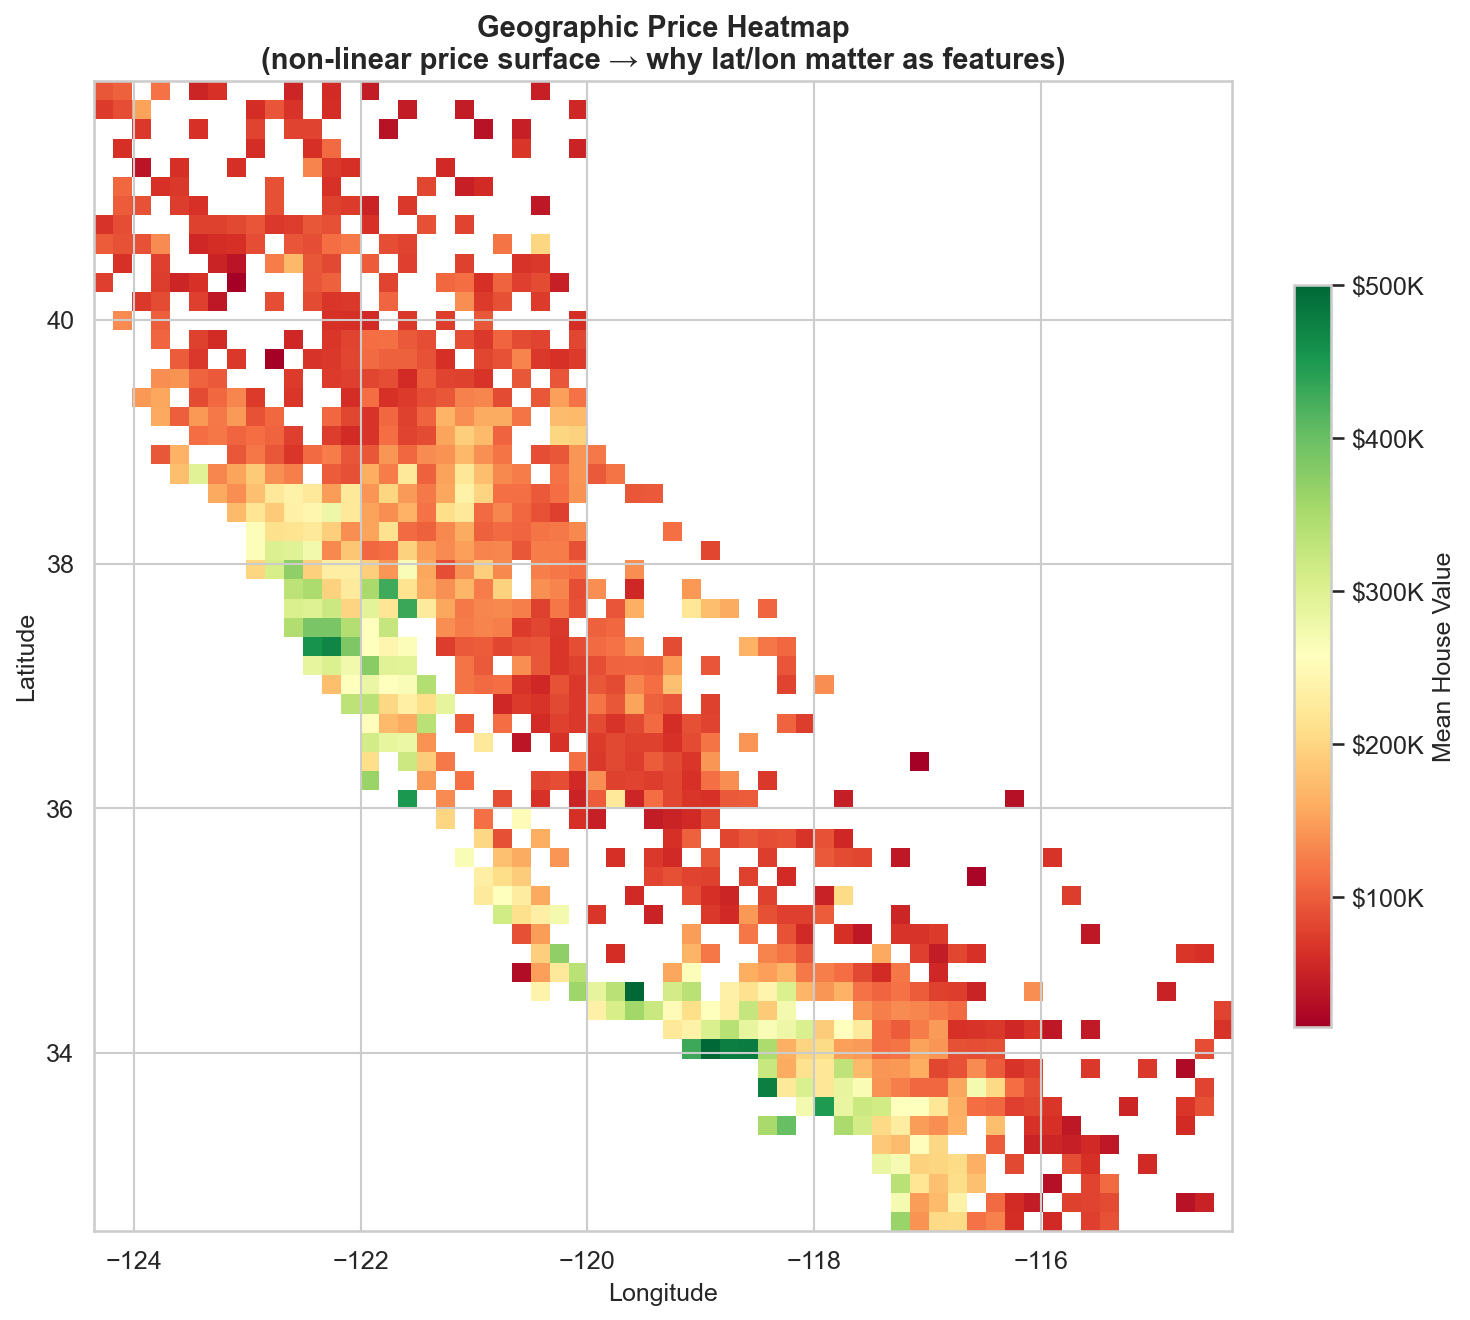

In [9]:
lat_bins = np.linspace(df['latitude'].min(),  df['latitude'].max(),  61)
lon_bins = np.linspace(df['longitude'].min(), df['longitude'].max(), 61)

df['lat_bin'] = pd.cut(df['latitude'],  bins=lat_bins,  labels=False)
df['lon_bin'] = pd.cut(df['longitude'], bins=lon_bins,  labels=False)

grid = df.groupby(['lat_bin','lon_bin'])[TARGET].mean().unstack()

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(
    grid.values,
    aspect='auto', origin='lower', cmap='RdYlGn',
    extent=[df['longitude'].min(), df['longitude'].max(),
            df['latitude'].min(),  df['latitude'].max()]
)
cbar = fig.colorbar(im, ax=ax, fraction=0.03)
cbar.set_label('Mean House Value', fontsize=LABEL_FS)
cbar.ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax.set_xlabel('Longitude', fontsize=LABEL_FS)
ax.set_ylabel('Latitude',  fontsize=LABEL_FS)
ax.set_title('Geographic Price Heatmap\n'
             '(non-linear price surface → why lat/lon matter as features)',
             fontsize=TITLE_FS, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/plot04_08_price_heatmap_grid.png', dpi=FIG_DPI)
plt.show()

---
### 📊 PLOT 9 — Latitude and Longitude Price Profiles (1D)
**What it shows:** Mean house value binned along latitude and longitude separately.  
**Presentation use:** Shows the non-linear price curve along each axis — the model must learn two separate 1D non-linear functions just for geography, which is why deep layers help.

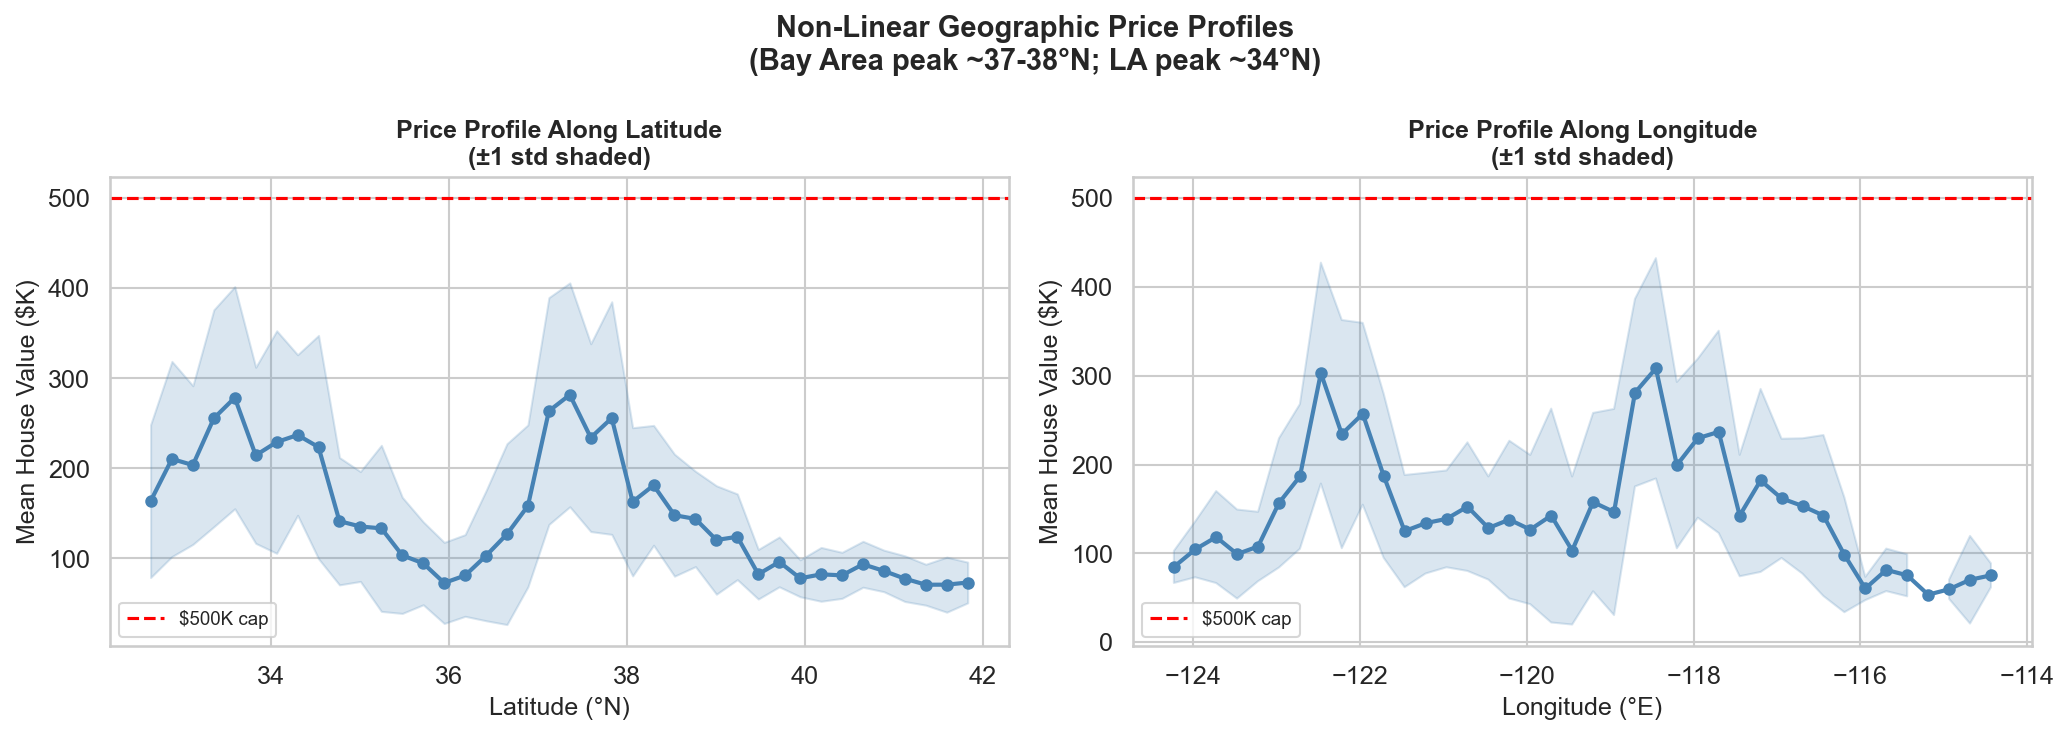

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, label in [
    (axes[0], 'latitude',  'Latitude (°N)'),
    (axes[1], 'longitude', 'Longitude (°E)'),
]:
    bins = pd.cut(df[col], bins=40)
    bin_means = df.groupby(bins)[TARGET].mean()
    bin_centers = [(b.left + b.right) / 2 for b in bin_means.index]
    bin_std = df.groupby(bins)[TARGET].std()

    ax.plot(bin_centers, bin_means.values / 1e3, 'o-', color='steelblue',
            linewidth=2, markersize=5)
    ax.fill_between(
        bin_centers,
        (bin_means - bin_std).values / 1e3,
        (bin_means + bin_std).values / 1e3,
        alpha=0.2, color='steelblue'
    )
    ax.axhline(CAP_USD / 1e3, color='red', linestyle='--',
               linewidth=1.5, label='$500K cap')
    ax.set_xlabel(label, fontsize=LABEL_FS)
    ax.set_ylabel('Mean House Value ($K)', fontsize=LABEL_FS)
    ax.set_title(f'Price Profile Along {col.capitalize()}\n(±1 std shaded)',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)

fig.suptitle('Non-Linear Geographic Price Profiles\n'
             '(Bay Area peak ~37-38°N; LA peak ~34°N)',
             fontsize=TITLE_FS, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/plot04_09_lat_lon_price_profile.png', dpi=FIG_DPI)
plt.show()

---
## 5 · Training Data Descriptive Statistics
### 📊 PLOT 10 — Training Set Summary Statistics Table
**What it shows:** Visual table of mean, std, min, 25th/50th/75th percentile, max for all features — in their standardised form.  
**Presentation use:** Shows the input distribution the MLP actually trained on; useful for explaining why certain inputs may cause extrapolation errors.

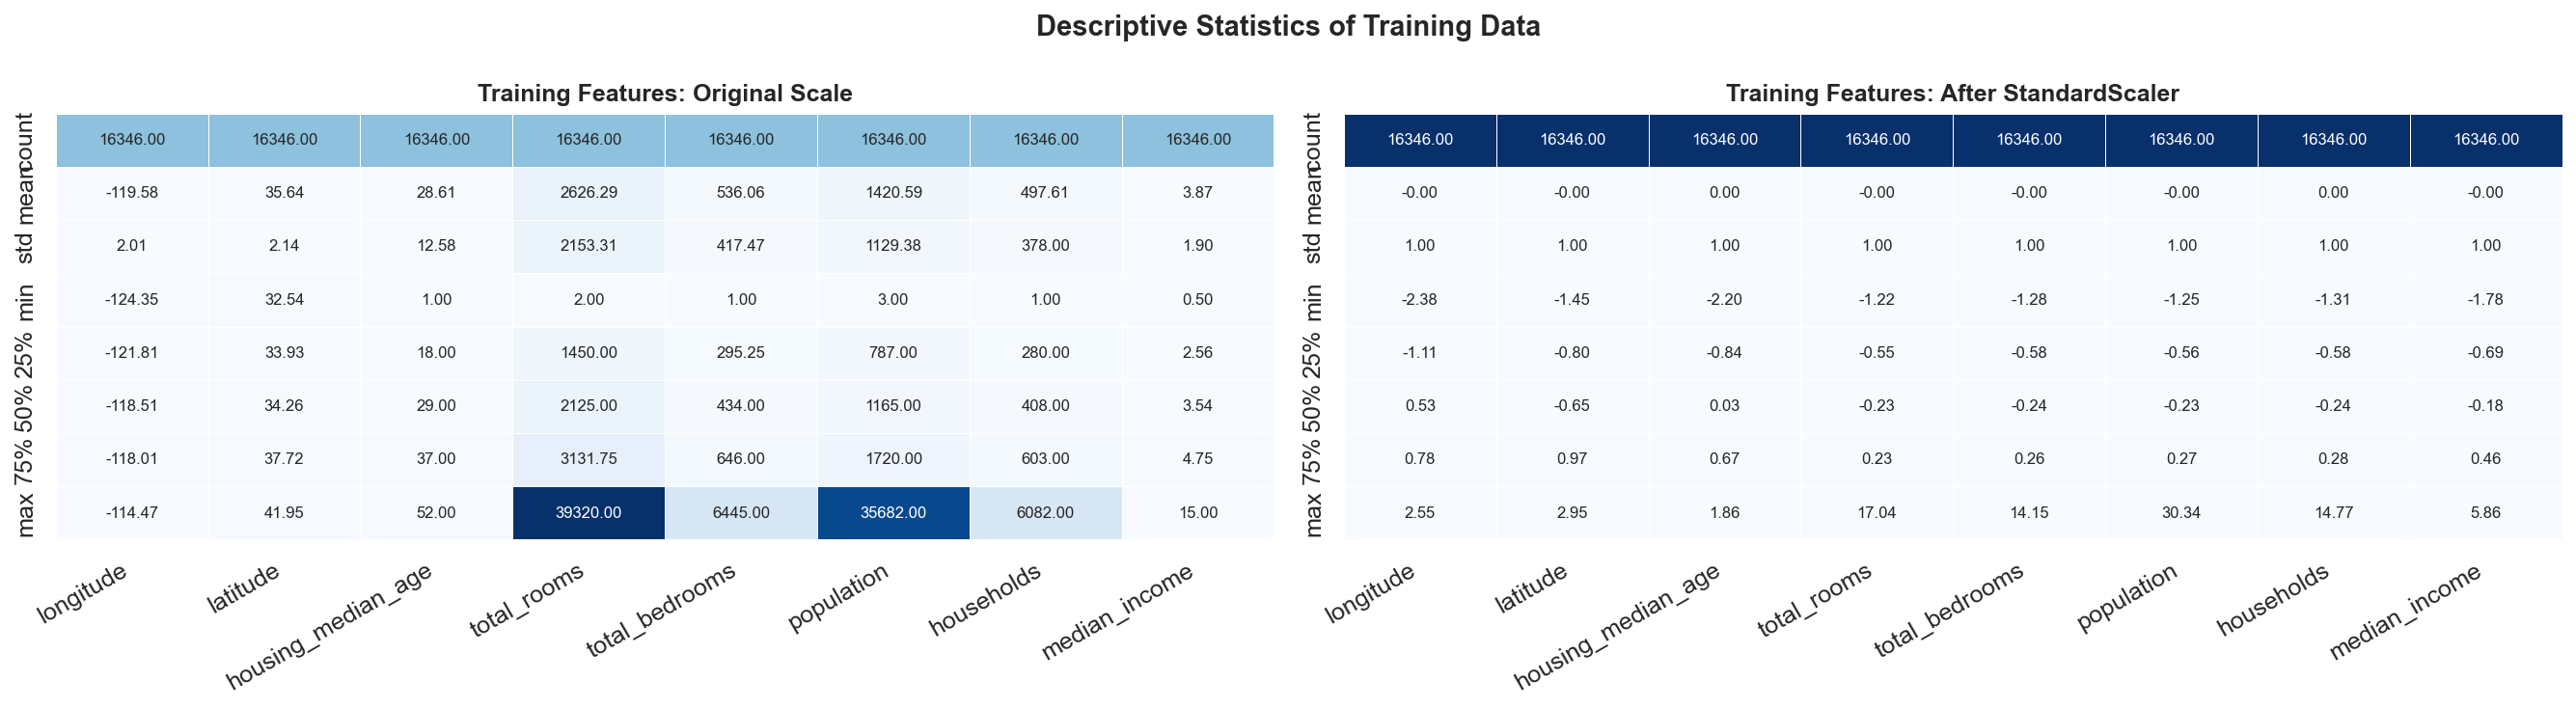

In [11]:
df_train_original = df.iloc[list(idx_tr)][NUMERIC].describe().round(3)
df_train_scaled   = pd.DataFrame(X_train[:, :8], columns=NUMERIC).describe().round(3)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

for ax, data, title in [
    (axes[0], df_train_original, 'Training Features: Original Scale'),
    (axes[1], df_train_scaled,   'Training Features: After StandardScaler'),
]:
    sns.heatmap(
        data, annot=True, fmt='.2f', cmap='Blues',
        linewidths=0.4, ax=ax, cbar=False,
        annot_kws={'size': 8}
    )
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')

fig.suptitle('Descriptive Statistics of Training Data',
             fontsize=TITLE_FS, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/plot04_10_descriptive_stats_heatmap.png', dpi=FIG_DPI)
plt.show()

---
### 📊 PLOT 11 — Housing Age Distribution + Price by Age Bin
**What it shows:** Two panels — histogram of `housing_median_age` and mean price per age bin.  
**Presentation use:** Shows that older housing isn't necessarily cheaper — location confounds age effects, so `housing_median_age` alone has low predictive power (r≈0.11).

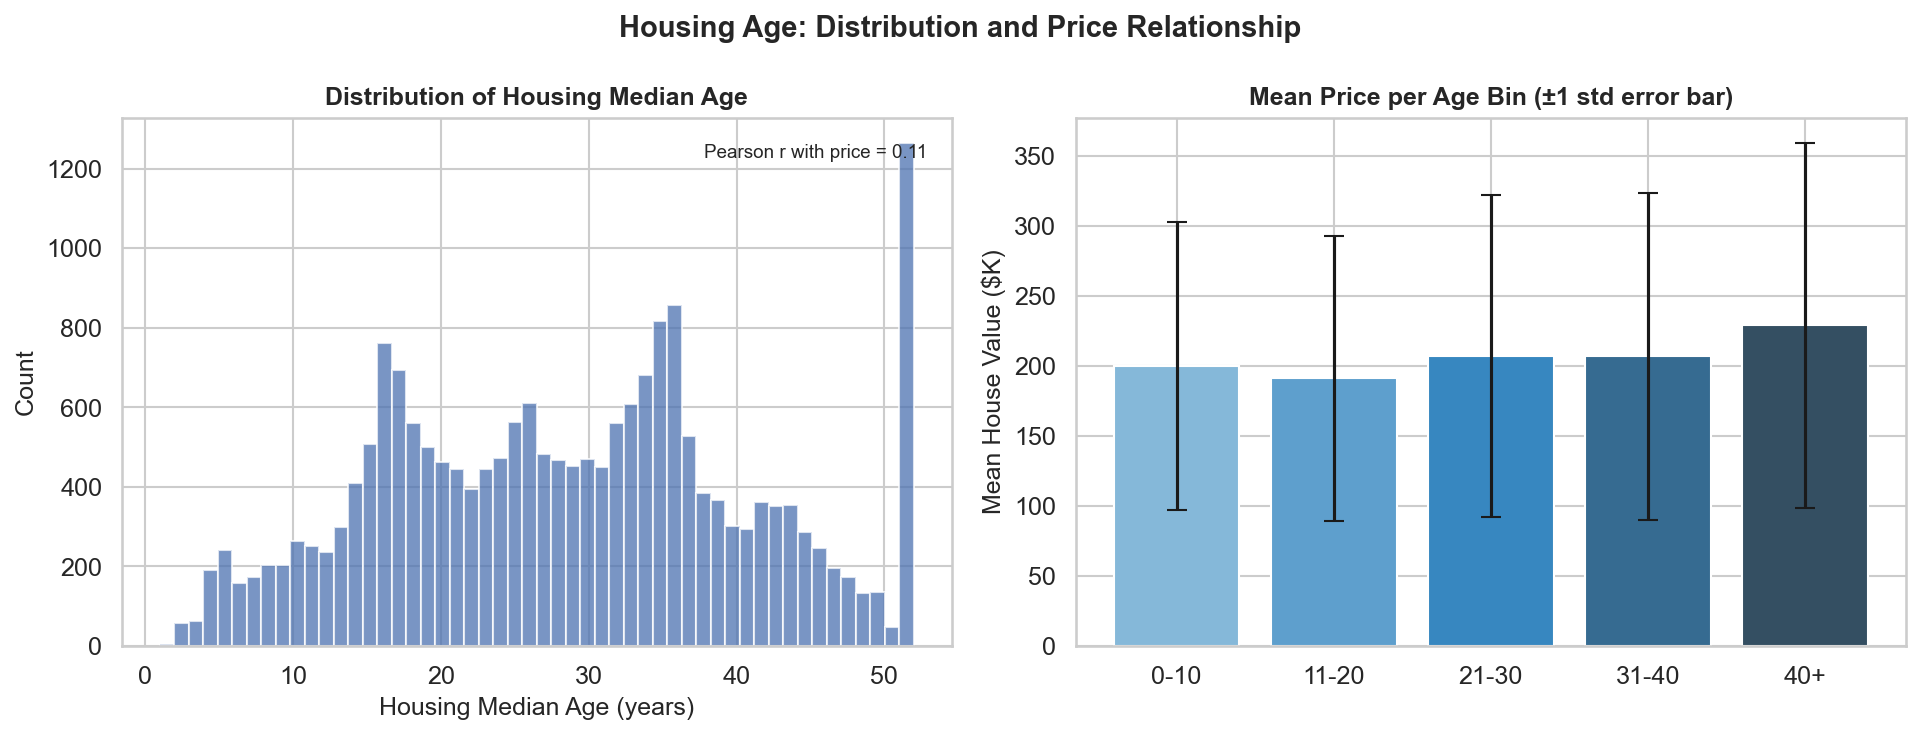

In [12]:
age_bins   = [0, 10, 20, 30, 40, 52]
age_labels = ['0-10','11-20','21-30','31-40','40+']
df['age_bin'] = pd.cut(df['housing_median_age'], bins=age_bins, labels=age_labels)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(df['housing_median_age'], bins=52, color='#4C72B0', alpha=0.75, edgecolor='white')
axes[0].set_xlabel('Housing Median Age (years)', fontsize=LABEL_FS)
axes[0].set_ylabel('Count', fontsize=LABEL_FS)
axes[0].set_title('Distribution of Housing Median Age', fontsize=12, fontweight='bold')
note = f'Pearson r with price = {df["housing_median_age"].corr(df[TARGET]):.2f}'
axes[0].text(0.97, 0.95, note, transform=axes[0].transAxes,
             ha='right', va='top', fontsize=9)

age_means = df.groupby('age_bin')[TARGET].mean()
age_std   = df.groupby('age_bin')[TARGET].std()
x = np.arange(len(age_labels))
axes[1].bar(x, age_means.values / 1e3,
            yerr=age_std.values / 1e3,
            color=sns.color_palette('Blues_d', len(age_labels)),
            edgecolor='white', capsize=5)
axes[1].set_xticks(x)
axes[1].set_xticklabels(age_labels)
axes[1].set_ylabel('Mean House Value ($K)', fontsize=LABEL_FS)
axes[1].set_title('Mean Price per Age Bin (±1 std error bar)', fontsize=12, fontweight='bold')

fig.suptitle('Housing Age: Distribution and Price Relationship',
             fontsize=TITLE_FS, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/plot04_11_age_analysis.png', dpi=FIG_DPI)
plt.show()

---
### 📊 PLOT 12 — Multicollinearity: Highly Correlated Feature Pairs
**What it shows:** Scatter matrix of the four strongly correlated count features.  
**Presentation use:** `total_rooms`, `total_bedrooms`, `population`, `households` are nearly collinear (r > 0.9) — the MLP's weights for these features are redundant and unstable.

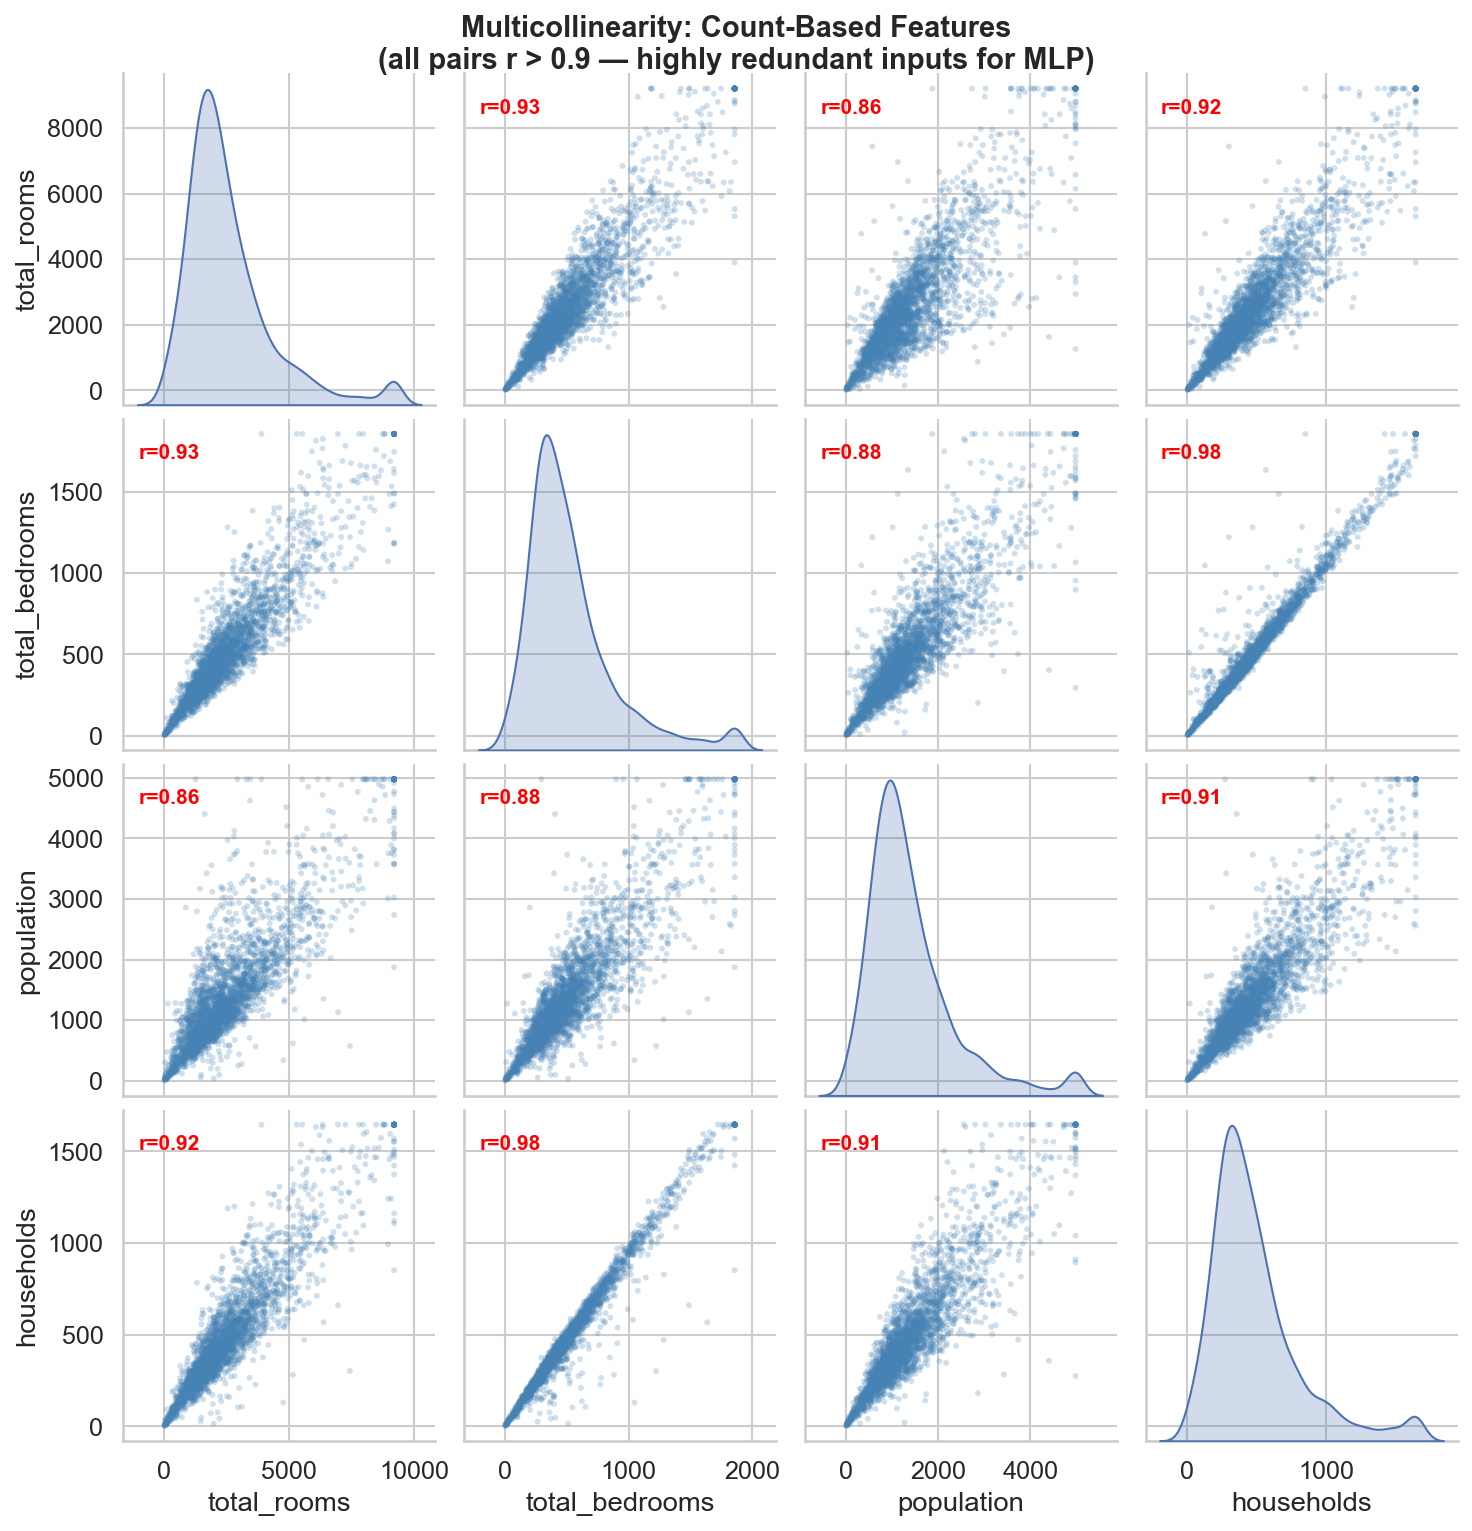

In [13]:
count_cols = ['total_rooms','total_bedrooms','population','households']
sample_mc  = df[count_cols].sample(3000, random_state=42)

# Clip outliers for readability
for col in count_cols:
    sample_mc[col] = sample_mc[col].clip(upper=sample_mc[col].quantile(0.98))

pg = sns.pairplot(
    sample_mc,
    plot_kws={'alpha': 0.25, 's': 8, 'color': 'steelblue', 'edgecolors': 'none'},
    diag_kind='kde'
)
# Annotate correlation on upper triangle
for i in range(len(count_cols)):
    for j in range(len(count_cols)):
        if i != j:
            r = df[count_cols[i]].corr(df[count_cols[j]])
            pg.axes[i][j].annotate(f'r={r:.2f}',
                                   xy=(0.05, 0.88), xycoords='axes fraction',
                                   fontsize=10, fontweight='bold', color='red')

pg.figure.suptitle('Multicollinearity: Count-Based Features\n'
                   '(all pairs r > 0.9 — highly redundant inputs for MLP)',
                   y=1.02, fontsize=TITLE_FS, fontweight='bold')
pg.figure.savefig(f'{VIZ_DIR}/plot04_12_multicollinearity_pairplot.png',
                  dpi=FIG_DPI, bbox_inches='tight')
plt.show()

---
## Summary — Notebook 04

| Plot | File | Key Takeaway for Presentation |
|------|------|-------------------------------|
| 1 | plot04_01_distribution_fitting | Target is log-normal; explains why MSE loss behaves asymmetrically |
| 2 | plot04_02_qq_plots | Non-normality confirmed; log transform would improve this |
| 3 | plot04_03_price_cap_analysis | ~4% of training data is hard-capped; NEAR BAY/OCEAN most affected |
| 4 | plot04_04_capped_geo_map | Cap issues concentrated in Bay Area and LA coastal zones |
| 5 | plot04_05_anova_ocean_proximity | Five one-hot groups are statistically distinct (p << 0.001) |
| 6 | plot04_06_iqr_outliers | Count features have 20-30% IQR outliers — extreme model inputs |
| 7 | plot04_07_features_by_proximity | ISLAND/NEAR BAY have distinct feature profiles the model must learn |
| 8 | plot04_08_price_heatmap_grid | Highly non-linear price surface → justifies deep architecture |
| 9 | plot04_09_lat_lon_price_profile | Two clear peaks (Bay Area, LA) along latitude axis |
| 10 | plot04_10_descriptive_stats_heatmap | Post-scaling: all features normalised to mean≈0, std≈1 |
| 11 | plot04_11_age_analysis | Age has weak predictive power (r≈0.11) — location dominates |
| 12 | plot04_12_multicollinearity_pairplot | Count features are >0.9 correlated — near-redundant MLP inputs |